# OULAD: обучение DeepFM+SVD++ и Dueling DQN

Ноутбук повторяет `python -m src.cli train static` и `train dqn` для OULAD.

Ожидаемые артефакты:
* `results/<run>/checkpoints/deepfm_best.pth`
* `results/<run>/checkpoints/dqn_best.pth`
* `results/<run>/tables/history.json` с историей обучения
* `results/<run>/figures/` - кривые loss/reward.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import api

config = api.build_config(
    "oulad",
    yaml_path=str(ROOT / "configs" / "oulad.yaml"),
    overrides={
        "model": {"deepfm": {"n_epochs": 5, "batch_size": 512}},
        "training": {"dqn": {"n_episodes": 20, "max_steps_per_episode": 20}},
    },
)
run_dir = api.prepare_run(config, run_name="oulad_notebook")
print("Run directory:", run_dir)

2026-04-23 17:25:11 | INFO | rec_sys_edu | Запуск: results\oulad_notebook_20260423_172511
Run directory: results\oulad_notebook_20260423_172511


## 1. DeepFM+SVD++ (прокси-критерии OULAD)

In [2]:
static = api.train_static("oulad", config=config, run_dir=run_dir)
history = static["history"]
print("best_val_loss:", history.get("best_val_loss"))
print("checkpoint:", history.get("best_checkpoint"))

2026-04-23 17:29:05 | INFO | rec_sys_edu | OULAD bundle: users=29632, items=18, step_rows=2318825
2026-04-23 17:29:08 | INFO | rec_sys_edu | Static model: 29632 users, 18 items, 4 heads
2026-04-23 17:30:26 | INFO | rec_sys_edu | Epoch 1/5 - train_loss=0.0077, val_loss=0.0033
2026-04-23 17:30:26 | INFO | rec_sys_edu | Saved best model: results\oulad_notebook_20260423_172511\models\deepfm_oulad_best.pth (val_loss=0.0033)
2026-04-23 17:31:54 | INFO | rec_sys_edu | Epoch 2/5 - train_loss=0.0037, val_loss=0.0029
2026-04-23 17:31:54 | INFO | rec_sys_edu | Saved best model: results\oulad_notebook_20260423_172511\models\deepfm_oulad_best.pth (val_loss=0.0029)
2026-04-23 17:33:24 | INFO | rec_sys_edu | Epoch 3/5 - train_loss=0.0033, val_loss=0.0028
2026-04-23 17:33:24 | INFO | rec_sys_edu | Saved best model: results\oulad_notebook_20260423_172511\models\deepfm_oulad_best.pth (val_loss=0.0028)
2026-04-23 17:34:55 | INFO | rec_sys_edu | Epoch 4/5 - train_loss=0.0032, val_loss=0.0026
2026-04-23 17

## 2. Dueling DQN поверх DeepFM

Используем полученный чекпоинт DeepFM для инициализации окружения (эмбеддинги + предсказания прокси) и обучаем агента.

In [5]:
dqn_result = api.train_dqn(
    "oulad",
    config=config,
    run_dir=run_dir,
    deepfm_checkpoint=history.get("best_checkpoint"),
)
print("DQN-чекпоинт:", dqn_result["checkpoint"])
final = dqn_result["history"].get("final_evaluation", {})
print("final_evaluation:", final)

2026-04-23 17:45:30 | INFO | rec_sys_edu | OULAD bundle: users=29632, items=18, step_rows=2318825
Инициализация тренера на cpu
  Gamma: 0.95
  Learning rate: 0.0005
  Batch size: 128
  Epsilon: 1.0 -> 0.05
Запуск обучения на 20 эпизодов...


100%|██████████| 20/20 [00:08<00:00,  2.45it/s]



Обучение завершено!
Чекпоинт сохранен: results\oulad_notebook_20260423_172511\models\dqn_oulad_checkpoint.pth
2026-04-23 17:45:41 | INFO | rec_sys_edu | DQN training completed: episodes=20, final epsilon=0.257, mean_reward=1.220
DQN-чекпоинт: results\oulad_notebook_20260423_172511\models\dqn_oulad_checkpoint.pth
final_evaluation: {'mean_reward': np.float64(1.2198004985757875), 'std_reward': np.float64(0.8621637167503793), 'min_reward': np.float64(0.10523381146521038), 'max_reward': np.float64(2.535964784212432)}


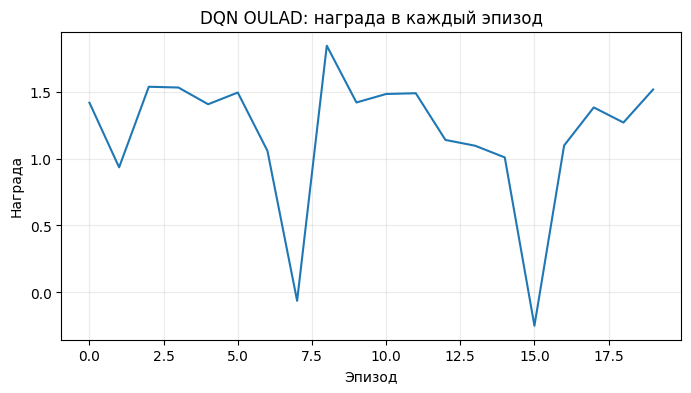

In [8]:
%matplotlib inline
import json, matplotlib.pyplot as plt

history_path = Path(run_dir) / "tables" / "dqn_history.json"
if history_path.exists():
    hist = json.loads(history_path.read_text(encoding="utf-8"))
    rewards = hist.get("training_rewards", [])
    plt.figure(figsize=(8, 4))
    plt.plot(rewards)
    plt.title("DQN OULAD: награда в каждый эпизод")
    plt.xlabel("Эпизод")
    plt.ylabel("Награда")
    plt.grid(alpha=0.25)
    plt.show()